In [1]:
import sys
from pathlib import Path
import importlib

project_root = Path.cwd().resolve().parents[1]
src_path = str(project_root / 'src')
if src_path not in sys.path:
    sys.path.insert(0, src_path)
sys.path.append(str(project_root / 'src' / 'fluprofiler'))

# Backward-compatible module alias for legacy checkpoints serialized with fluProfiler_models
# Force-refresh in case the current kernel previously mapped fluProfiler_models to a wrong module.
if 'fluProfiler_models' in sys.modules:
    del sys.modules['fluProfiler_models']
importlib.invalidate_caches()
old_mod = importlib.import_module('fluProfiler_models')
sys.modules['fluProfiler_models'] = old_mod

# Minimal symbol check for robust unpickling
required_symbols = ['fluProfiler_HANA', 'MaskedMSELoss', 'attention_mask']
missing_symbols = [name for name in required_symbols if not hasattr(old_mod, name)]
if missing_symbols:
    raise RuntimeError(f'fluProfiler_models missing symbols: {missing_symbols}')
checkpoint_path = project_root / 'runs' / 'holdout_tests' / 'titer' / '2025-08-19_17-43-32.pth'
from tqdm import tqdm
import os
import torch
import pandas as pd
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from utilities import load_embedding, print_exams
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from torch.utils.data import Dataset, DataLoader
from sklearn.decomposition import PCA
from joblib import Parallel, delayed
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import pandas as pd
import numpy as np

# 設置設備
device = torch.device('cuda:2')

class fluProfiler_Dataset(Dataset):
    def __init__(self, DataFrame):
        # 生成嵌入文件名
        self.emb_file_name_a = ('matrix_' + DataFrame['seq_id_a']).tolist()
        self.emb_file_name_b = ('matrix_' + DataFrame['seq_id_b']).tolist()
        self.emb_file_name_c = ('matrix_' + DataFrame['seq_id_c']).tolist()
        self.emb_file_name_d = ('matrix_' + DataFrame['seq_id_d']).tolist()

        # 轉換傳代類別為張量
        self.strainPassCats = convert_Pass2tensor(
            ('<cls>' + DataFrame['serumPassCat'] + '<eos>' + 
             DataFrame['virusPassCat'] + '<eos>').tolist()
        )
        
        # 標籤
        self.labels = torch.tensor(DataFrame['label'].tolist())
    
    def __len__(self):
        return len(self.labels)
    
    def __getitem__(self, idx):
        return (self.emb_file_name_a[idx], self.emb_file_name_b[idx], 
                self.emb_file_name_c[idx], self.emb_file_name_d[idx], 
                self.strainPassCats[idx], self.labels[idx])

def convert_Pass2tensor(pass_cats):
    result = [
        item.replace('<cls>', '0').replace('<eos>', '1')
             .replace('<EGG>', '2').replace('<CELL>', '3').replace('<BOTH>', '4')
        for item in pass_cats
    ]
    result = torch.tensor([[int(number) for number in [char for char in item]] for item in result])
    return result

def generate_matrix(matrix_list):
    seq_len = [mat.shape[0] for mat in matrix_list]
    max_len = max(seq_len)
    mask_list = []
    
    for i in range(len(matrix_list)): 
        # 填充矩陣到最大長度
        matrix_list[i] = F.pad(matrix_list[i], (0, 0, 0, max_len - seq_len[i]))
        mask = torch.concat((torch.ones(1,seq_len[i]),torch.zeros(1,max_len-seq_len[i])),axis=1)
        mask_list.append(mask)
    
    matrix = torch.stack(matrix_list)
    mask = torch.stack(mask_list).view(len(matrix_list), max_len)
    return matrix, mask

def list2df(mylist, period):
    merged_rows = []
    for i in range(0, len(mylist), period):
        merged_row = []
        for j in range(period):
            merged_row += mylist[i + j]
        merged_rows.append(merged_row)
    return pd.DataFrame(merged_rows)

In [2]:
def cluster_virus(df, vector, drop_duplicate=False):

    if drop_duplicate:
        df_arr = pd.DataFrame(vector, columns=[f'col_{i}' for i in range(vector.shape[1])])
        df_merged = pd.concat([df.reset_index(drop=True), df_arr], axis=1)
        df_merged["virusDate"] = pd.to_datetime(df_merged["virusDate"], errors="coerce")
        
        aggregate_dict = {col: 'first' for col in df_merged.columns if col != 'seq_c'}
        aggregate_dict['virusDate'] = 'min'
        df_agg = df_merged.groupby('seq_c').agg(aggregate_dict).reset_index()
        df = df_agg.iloc[:, :-2560]
        vector = np.array(df_agg.iloc[:, -2560:])

    # elbow_method(vector)
    
    pca_2d = PCA(n_components=2, random_state=42)
    X_2d = pca_2d.fit_transform(vector)

    k = 2
    labels = KMeans(n_clusters=k, random_state=441).fit_predict(X_2d)
    
    df_plot = pd.DataFrame(X_2d, columns=['x', 'y'])
    df_plot['cluster'] = labels.astype(str)
    df_plot['type'] = df['Type'].tolist()
    df_plot['virusDate'] = df['virusDate']
    df_plot['virusIslID'] = df['virusIslID'].tolist()

    return df_plot

def plot_virus_scatter(df_plot, color_map=None, save_path=None):
    plt.figure(figsize=(5, 3.5))

    order = ['Crick', 'CDC', 'CNIC']  # 你想要的顺序

    for t in order:
        subdf = df_plot[df_plot['type'] == t]  # 筛选对应类型的数据
        if len(subdf) == 0:
            continue  # 防止某类不存在时报错

        plt.scatter(subdf["x"], subdf["y"],
                    label=t,
                    c=color_map.get(t, "gray"),
                    s=8, alpha=0.45, lw=0)

    # ===== 样式 =====
    plt.xlabel("component-1", fontsize=14)
    plt.ylabel("component-2", fontsize=14)
    
    plt.legend(frameon=False, fontsize=10, loc='upper left', bbox_to_anchor=(0.98, 1), 
    markerscale=2, alignment='left')

    plt.grid(True, linestyle="--", alpha=0.3)
    plt.tight_layout()
    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['right'].set_visible(False)
    
    if save_path is not None:
        ext = os.path.splitext(save_path)[1].lower()

        if ext == '.png':
            plt.savefig(save_path, dpi=600, transparent=True,
                        pil_kwargs={"compress_level": 0}, bbox_inches="tight")
        elif ext == '.svg':
            plt.savefig(save_path, format='svg', bbox_inches="tight")
    else:
        plt.show()

def plot_virus_scatter_time(df_plot, save_path=None):
    """
    根据virusDate由浅到深绘制散点（自然色渐变：蓝→绿→黄）。
    """
    fig, ax = plt.subplots(figsize=(7, 3.5))

    # 确保时间格式并去掉NaT
    df_plot = df_plot.copy()
    df_plot["virusDate"] = pd.to_datetime(df_plot["virusDate"], errors="coerce")
    df_plot = df_plot.dropna(subset=["virusDate"])
    if df_plot.empty:
        raise ValueError("virusDate 列全部为空或无法解析为日期")

    # 按时间排序（保证后期点覆盖早期点）
    df_plot = df_plot.sort_values("virusDate")

    # 时间归一化（排除极端值，避免色带压缩）
    vmin = df_plot["virusDate"].quantile(0.05).timestamp()
    vmax = df_plot["virusDate"].quantile(0.95).timestamp()
    norm = mcolors.Normalize(vmin=vmin, vmax=vmax)

    # 自然色 colormap
    cmap = plt.get_cmap("cividis")

    # 绘制散点
    sc = ax.scatter(df_plot["x"], df_plot["y"],
                    c=df_plot["virusDate"].apply(lambda x: x.timestamp()),
                    cmap=cmap, norm=norm,
                    s=6, alpha=0.6, lw=0)

    # 颜色条
    sm = cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, fraction=0.02, pad=0.02)
    ticks = np.linspace(vmin, vmax, 6)
    cbar.set_ticks(ticks)
    cbar.set_ticklabels(pd.to_datetime(ticks, unit="s").strftime("%Y"))  # 只显示年份
    cbar.set_label("Isolation year", fontsize=10)

    # 样式
    ax.set_xlabel("PC1", fontsize=10)
    ax.set_ylabel("PC2", fontsize=10)
    # ax.grid(True, linestyle="--", alpha=0.25)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    # ax.set_aspect('equal')

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=600, transparent=True,
                    bbox_inches="tight", pil_kwargs={"compress_level": 0})
    else:
        plt.show()

def plot_virus_scatter_time_nature(df_plot, save_path=None, title=None):
    """
    Nature-style scatter by virusDate.

    Parameters
    ----------
    df_plot : pd.DataFrame
        必须包含 ['x', 'y', 'virusDate'] 三列。
    save_path : str or None
        输出路径，支持 .png/.svg。None 时直接显示。
    title : str or None
        可选标题。
    """
    required_cols = {"x", "y", "virusDate"}
    missing = required_cols - set(df_plot.columns)
    if missing:
        raise ValueError(f"缺少必要列: {sorted(missing)}")

    # 复制并清洗日期
    d = df_plot.copy()
    d["virusDate"] = pd.to_datetime(d["virusDate"], errors="coerce")
    d = d.dropna(subset=["virusDate", "x", "y"]).sort_values("virusDate")
    if d.empty:
        raise ValueError("有效数据为空：请检查 virusDate/x/y 是否可解析")

    # 局部风格设置，避免污染全局 rcParams
    with plt.style.context("default"):
        plt.rcParams.update({
            "font.family": "DejaVu Sans",
            "font.size": 9,
            "axes.labelsize": 10,
            "xtick.labelsize": 8.5,
            "ytick.labelsize": 8.5,
        })

        fig, ax = plt.subplots(figsize=(5.1, 3.6), dpi=260)

        # 用分位数压掉极端年份，色带更均衡
        t = d["virusDate"].map(pd.Timestamp.timestamp).to_numpy()
        vmin, vmax = np.quantile(t, [0.03, 0.97])
        norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
        cmap = plt.get_cmap("cividis")

        ax.scatter(
            d["x"],
            d["y"],
            c=t,
            cmap=cmap,
            norm=norm,
            s=15,
            alpha=0.86,
            linewidths=0.22,
            edgecolors="white",
            rasterized=True,
            zorder=2,
        )

        # 轻网格 + 干净坐标轴
        ax.grid(True, linestyle="-", linewidth=0.45, alpha=0.16, color="#8a8a8a")
        ax.set_axisbelow(True)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.spines["left"].set_linewidth(0.8)
        ax.spines["bottom"].set_linewidth(0.8)
        ax.tick_params(direction="out", width=0.8, length=3)

        ax.set_xlabel("Component 1")
        ax.set_ylabel("Component 2")
        if title:
            ax.set_title(title, pad=5)

        # 窄 colorbar（更像期刊图）
        sm = cm.ScalarMappable(norm=norm, cmap=cmap)
        sm.set_array([])
        cbar = fig.colorbar(sm, ax=ax, fraction=0.03, pad=0.02, shrink=0.92)
        ticks = np.linspace(vmin, vmax, 5)
        cbar.set_ticks(ticks)
        cbar.set_ticklabels(pd.to_datetime(ticks, unit="s").strftime("%Y"))
        cbar.set_label("Collection year", fontsize=8.8)
        cbar.ax.tick_params(labelsize=8)
        cbar.outline.set_linewidth(0.6)

        plt.tight_layout(pad=0.6)

        if save_path:
            ext = os.path.splitext(save_path)[1].lower()
            if ext == ".svg":
                plt.savefig(save_path, format="svg", bbox_inches="tight", transparent=True)
            else:
                plt.savefig(
                    save_path,
                    dpi=600,
                    bbox_inches="tight",
                    transparent=True,
                    pil_kwargs={"compress_level": 0},
                )
        else:
            plt.show()

def group_and_filt(DF):
    group_columns = ['seq_a', 'seq_b', 'seq_c', 'seq_d', 'serumPassCat', 'virusPassCat']
    agg_dict = {c: 'first' for c in DF.columns if c not in group_columns}
    agg_dict['label'] = 'mean'
    Active_final = DF.groupby(group_columns).agg(agg_dict).reset_index()
    
    return Active_final

def retrive_feature_vector(model, dataloader, emb_dict, device, emb_in_device=False, save_path=None):
    model.eval()
    Total_iter = len(dataloader)
    progress_bar = tqdm(range(Total_iter), desc="Retrive Feature Vector")
    for batch in dataloader:
        emb_file_name_a, emb_file_name_b, emb_file_name_c, emb_file_name_d, strainPassCats, labels = batch
        matrixs_a, masks_a = generate_matrix([emb_dict[key.replace('_active', '')] for key in emb_file_name_a])
        matrixs_b, masks_b = generate_matrix([emb_dict[key.replace('_active', '')] for key in emb_file_name_b])
        matrixs_c, masks_c = generate_matrix([emb_dict[key.replace('_active', '')] for key in emb_file_name_c])
        matrixs_d, masks_d = generate_matrix([emb_dict[key.replace('_active', '')] for key in emb_file_name_d])

        if emb_in_device == False:
            matrixs_a, matrixs_b, matrixs_c, matrixs_d = matrixs_a.to(device), matrixs_b.to(device), matrixs_c.to(device), matrixs_d.to(device)

        masks_a, masks_b, masks_c, masks_d = masks_a.to(device), masks_b.to(device), masks_c.to(device), masks_d.to(device)
        strainPassCats, labels = strainPassCats.to(device), labels.to(device)
        
        with torch.no_grad():
            loss, logits, output = model(matrices_a=matrixs_a, matrices_b=matrixs_b, matrices_c=matrixs_c, 
                                        matrices_d=matrixs_d, matrix_attention_masks_a=masks_a, matrix_attention_masks_b=masks_b, 
                                        matrix_attention_masks_c=masks_c, matrix_attention_masks_d=masks_d, strainPassCats=strainPassCats, labels=labels,
                                        save_concat_vector=save_path)

        progress_bar.update(1)
    progress_bar.close()



## 数据加载

In [3]:
All_data = pd.read_csv('../../data/active_learning/processed/All.csv')

In [4]:
Active_final = All_data[(All_data['sheet'].str.split('-').str[0].astype(int) >= 41) & 
                        (All_data['sheet'].str.split('-').str[0].astype(int) <= 42)]
Active_final = group_and_filt(Active_final)

Active_candidate, Active_test = train_test_split(Active_final, test_size=0.1, random_state=42)

Early_final = All_data[All_data['sheet'].str.split('-').str[0].astype(int) < 41]
Early_final = group_and_filt(Early_final)

In [5]:
print('Active_final:', len(Active_final))
print('Active_candidate:', len(Active_candidate))
print('Active_test:', len(Active_test))
print('Early_final:', len(Early_final))

Active_final: 10128
Active_candidate: 9115
Active_test: 1013
Early_final: 71915


In [6]:
batch_size = 8
Active_candidate_dataloader = DataLoader(fluProfiler_Dataset(Active_candidate), batch_size=128, shuffle=False)
Active_test_dataloader = DataLoader(fluProfiler_Dataset(Active_test), batch_size=batch_size, shuffle=False)

In [7]:
emb_files = 'matrix_' + pd.concat([Active_final['seq_id_a'], Active_final['seq_id_b'], 
            Active_final['seq_id_c'], Active_final['seq_id_d']]).drop_duplicates() + '.pt'
emb_dict = load_embedding(path='../../data/reverse_test/embedding/', files=emb_files, map_location=device)

Loading tensor: 100%|██████████| 1555/1555 [00:56<00:00, 27.58file/s]


### 聚类选择代表性样本

In [8]:
class Emb2Vec(nn.Module):
    def __init__(self, model):
        super(Emb2Vec, self).__init__()
        self.matrix_dropout = model.matrix_dropout
        self.matrix_pooler = model.matrix_pooler
        self.linear = model.linear[0][0]
        self.Gelu = model.linear[0][1]
        
    def forward(self, embedding):
        embedding = self.matrix_dropout(embedding)
        seq_vector = self.matrix_pooler(embedding)
        seq_vector = self.linear(seq_vector)
        return seq_vector

def run_emb2vec_on_dict(emb_dict, emb2vec, device='cpu'):
    emb2vec = emb2vec.to(device)
    emb2vec.eval()

    vec_dict = {}
    for k, emb in emb_dict.items():
        emb = emb.to(device)
        if emb.dim() == 2:   # (566, 2560) -> (1, 566, 2560)
            emb = emb.unsqueeze(0)

        with torch.no_grad():
            vec = emb2vec(emb)[0].cpu()   # (D_out,)
        vec_dict[k] = vec
    return vec_dict

In [9]:
model = torch.load(checkpoint_path, weights_only=False, map_location=device)
print(type(model), hasattr(model, 'loss_fct'))
embedding_pooler = Emb2Vec(model)
vector_dict = run_emb2vec_on_dict(emb_dict, embedding_pooler, device=device)

<class 'fluProfiler_models.fluProfiler_HANA'> True


In [10]:
virus_tensor_list = []
for row in Active_candidate.itertuples():
    HA_vector = vector_dict['matrix_' + row.seq_id_c]
    NA_vector = vector_dict['matrix_' + row.seq_id_d]
    HA_NA_vector = torch.cat([HA_vector, NA_vector], dim=0)
    virus_tensor_list.append(HA_NA_vector)
virus_tensor = torch.stack(virus_tensor_list)
virus_tensor.shape

torch.Size([9115, 512])

In [11]:
import csv
import numpy as np
from sklearn.cluster import KMeans
from torch.optim import AdamW
from IPython.display import clear_output

def select_representative_viruses(virus_emb, n_clusters=15):
    """
    对 virus embedding 聚类，并选出每个簇中离中心最近的 virus。
    
    参数:
        virus_emb: (N, d) 病毒 embedding
        n_clusters: 聚类数
        
    返回:
        selected_indices: 每个簇中代表性 virus 的原始行 index
    """
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10).fit(virus_emb)
    labels = kmeans.labels_
    centers = kmeans.cluster_centers_

    selected_indices = []
    for i in range(n_clusters):
        idx = np.where(labels == i)[0]
        if len(idx) == 0:
            continue
        cluster_points = virus_emb[idx]
        center = centers[i]
        dists = np.linalg.norm(cluster_points - center, axis=1)
        best_idx = idx[np.argmin(dists)]
        selected_indices.append(best_idx)

    return selected_indices

def log_metrics(epoch, test_mae, test_mse, test_pearson, test_spearman, R2, log_path):
    with open(log_path, "a", newline="") as f:
        writer = csv.writer(f)
        writer.writerow([epoch, test_mae, test_mse, test_pearson, test_spearman, R2])

def multidata_trainer(model, train_dataloader, test_dataloader, emb_dict, lr_rate, epoch=15, save_path=None, emb_in_device=False):
    model.to(device)
    if save_path is not None:
        from pathlib import Path
        Path(save_path).mkdir(parents=True, exist_ok=True)
    no_decay = ["bias", "layernorm.weight", "layer_norm.weight", "layer.norm.weight"]
    weight_decay = 0.01
    beta1 = 0.9
    beta2 = 0.99
    adam_epsilon = 1e-08

    optimizer_grouped_parameters = [{
                "params": [p for n, p in model.named_parameters() if not any(nd in n.lower() for nd in no_decay)],
                "weight_decay": weight_decay
            },
            {
                "params": [p for n, p in model.named_parameters() if any(nd in n.lower() for nd in no_decay)],
                "weight_decay": 0.0
            }
        ]
    optimizer = AdamW(optimizer_grouped_parameters,
                      lr=lr_rate,
                        betas=[beta1 if beta1 > 0 else 0.9, beta2 if beta2 > 0 else 0.98],
                        eps=adam_epsilon)

    

    test_MAE_ls = []
    test_MSE_ls = []
    test_Pearson_ls = []
    test_Spearman_ls = []
    test_R2_ls = []

    minimal_MSE = float('inf')
    for epoch in range(epoch):
        model.train()
        loss_ls = []
        for batch in train_dataloader:
            emb_file_name_a, emb_file_name_b, emb_file_name_c, emb_file_name_d, strainPassCats, labels = batch
            
            matrixs_a, masks_a = generate_matrix([emb_dict[key.replace('_active', '')] if key.endswith('_active') else emb_dict[key] for key in emb_file_name_a])
            matrixs_b, masks_b = generate_matrix([emb_dict[key.replace('_active', '')] if key.endswith('_active') else emb_dict[key] for key in emb_file_name_b])
            matrixs_c, masks_c = generate_matrix([emb_dict[key.replace('_active', '')] if key.endswith('_active') else emb_dict[key] for key in emb_file_name_c])
            matrixs_d, masks_d = generate_matrix([emb_dict[key.replace('_active', '')] if key.endswith('_active') else emb_dict[key] for key in emb_file_name_d])

            if not emb_in_device:
                matrixs_a, matrixs_b, matrixs_c, matrixs_d = matrixs_a.to(device), matrixs_b.to(device), matrixs_c.to(device), matrixs_d.to(device)
            
            masks_a, masks_b, masks_c, masks_d = masks_a.to(device), masks_b.to(device), masks_c.to(device), masks_d.to(device)
            strainPassCats, labels = strainPassCats.to(device), labels.to(device)
            loss, logits, output = model(matrices_a=matrixs_a, matrices_b=matrixs_b, matrices_c=matrixs_c, matrices_d=matrixs_d, 
                                        matrix_attention_masks_a=masks_a, matrix_attention_masks_b=masks_b, matrix_attention_masks_c=masks_c, 
                                        matrix_attention_masks_d=masks_d, strainPassCats=strainPassCats, labels=labels)
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
            loss_ls.append(loss.item())
        # print('The train loss: ',np.mean(loss_ls))

        test_prediction_ls = []
        test_reference_ls = []
        test_logits_ls = []
        model.eval()
        for batch in test_dataloader:
            with torch.no_grad():
                emb_file_name_a, emb_file_name_b, emb_file_name_c, emb_file_name_d, strainPassCats, labels = batch
                matrixs_a, masks_a = generate_matrix([emb_dict[key.replace('_active', '')] if key.endswith('_active') else emb_dict[key] for key in emb_file_name_a])
                matrixs_b, masks_b = generate_matrix([emb_dict[key.replace('_active', '')] if key.endswith('_active') else emb_dict[key] for key in emb_file_name_b])
                matrixs_c, masks_c = generate_matrix([emb_dict[key.replace('_active', '')] if key.endswith('_active') else emb_dict[key] for key in emb_file_name_c])
                matrixs_d, masks_d = generate_matrix([emb_dict[key.replace('_active', '')] if key.endswith('_active') else emb_dict[key] for key in emb_file_name_d])

                if not emb_in_device:
                    matrixs_a, matrixs_b, matrixs_c, matrixs_d = matrixs_a.to(device), matrixs_b.to(device), matrixs_c.to(device), matrixs_d.to(device)
                masks_a, masks_b, masks_c, masks_d, strainPassCats, labels = masks_a.to(device), masks_b.to(device), masks_c.to(device), masks_d.to(device), strainPassCats.to(device), labels.to(device)
                loss, logits, output = model(matrices_a=matrixs_a, matrices_b=matrixs_b, matrices_c=matrixs_c, matrices_d=matrixs_d, 
                                            matrix_attention_masks_a=masks_a, matrix_attention_masks_b=masks_b, matrix_attention_masks_c=masks_c, 
                                            matrix_attention_masks_d=masks_d, strainPassCats=strainPassCats, labels=labels)
            test_prediction_ls = test_prediction_ls + output.view(-1).tolist()
            test_reference_ls = test_reference_ls + labels.tolist()
            test_logits_ls.append(logits.tolist())
        
        test_mae, test_mse, test_pearson, test_spearman, R2 = print_exams(test_reference_ls, test_prediction_ls, print_result=False)
        test_MAE_ls.append(test_mae)
        test_MSE_ls.append(test_mse)
        test_Pearson_ls.append(test_pearson)
        test_Spearman_ls.append(test_spearman)
        test_R2_ls.append(R2)
        
        if test_mse < minimal_MSE:
            minimal_MSE = test_mse
            torch.save(model, save_path + 'model.pth')

        log_metrics(epoch, test_mae, test_mse, test_pearson, test_spearman, R2, save_path + 'log.csv') 


        epochs = list(range(1, len(test_MSE_ls)+1))

        # 绘制折线图
        plt.figure(figsize=(10, 6))
        plt.plot(epochs, test_MSE_ls, label='test MSE', marker='x')

        plt.text(epochs[-1], test_MSE_ls[-1], f'{test_MSE_ls[-1]:.5f}', ha='center', va='top')

        # 添加标题和标签
        plt.title('MSE Changes Over Epochs')
        plt.xlabel('Epochs')
        plt.ylabel('MSE')
        plt.legend()
        clear_output(wait=True)
        plt.show()
            
        
    return [test_MAE_ls, test_MSE_ls, test_Pearson_ls, test_Spearman_ls, test_R2_ls]

In [21]:
from pathlib import Path

sample_virus_size = 300
absolute_path = '../../runs/active_learning/seasonal/'

unique_virus_emb, selected_indices = np.unique(virus_tensor, axis=0, return_index=True)
virus_df = Active_candidate.copy().reset_index(drop=True).iloc[selected_indices]

active_selected_virus = select_representative_viruses(unique_virus_emb, n_clusters=sample_virus_size)
active_selected = virus_df.iloc[active_selected_virus][['seq_id_c', 'seq_id_d']].merge(Active_candidate, on=['seq_id_c', 'seq_id_d'], how='left')

random_selected_virus = virus_df.sample(len(active_selected_virus), random_state=42)
random_selected = random_selected_virus[['seq_id_c', 'seq_id_d']]. \
    merge(Active_candidate, on=['seq_id_c', 'seq_id_d'], how='left')

if len(active_selected) < len(random_selected):
    random_selected = random_selected.sample(len(active_selected), random_state=42)
else:
    active_selected = active_selected.sample(len(random_selected), random_state=42)

save_dir = Path(absolute_path) / str(sample_virus_size)
save_dir.mkdir(parents=True, exist_ok=True)

active_selected.to_csv(save_dir / 'active_selected.csv', index=False)
random_selected.to_csv(save_dir / 'random_selected.csv', index=False)

active_dataloader = DataLoader(fluProfiler_Dataset(active_selected), batch_size=4, shuffle=True)
random_dataloader = DataLoader(fluProfiler_Dataset(random_selected), batch_size=4, shuffle=True)

print('Active selection size: ', len(active_selected))
print('Random selection size: ', len(random_selected))

Active selection size:  2205
Random selection size:  2205


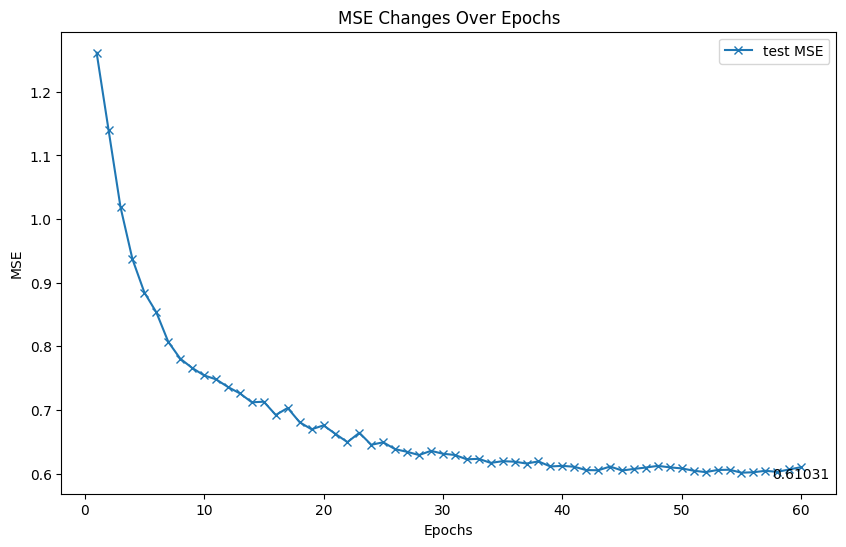

In [22]:
model_active = torch.load(checkpoint_path, weights_only=False, map_location=device)
active_result = multidata_trainer(model_active, active_dataloader, Active_test_dataloader, emb_dict, 
lr_rate=0.00001, epoch=60, save_path=absolute_path + str(sample_virus_size) + '/active/', emb_in_device=True)

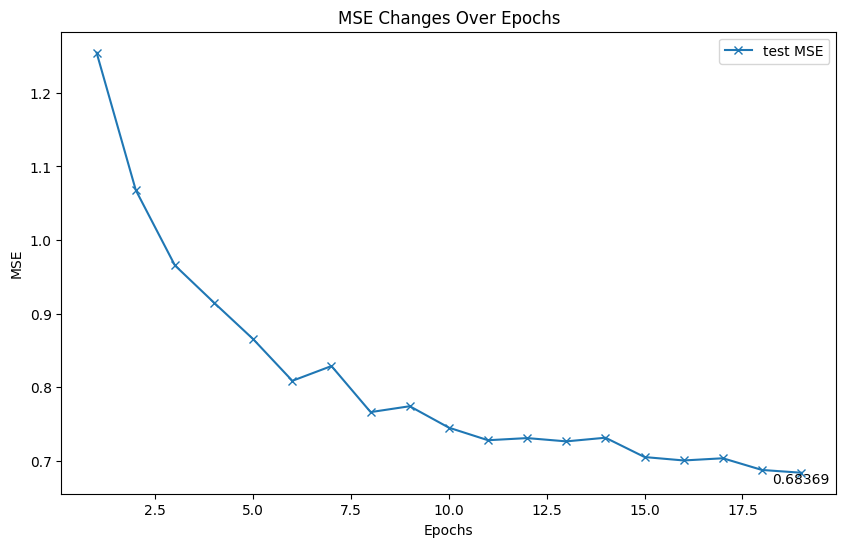

In [ ]:
model_random = torch.load(checkpoint_path, weights_only=False, map_location=device)
random_result = multidata_trainer(model_random, random_dataloader, Active_test_dataloader, emb_dict, 
lr_rate=0.00001, epoch=60, save_path=absolute_path + str(sample_virus_size) + '/random/', emb_in_device=True)